# <span style='color:Red'>Data preprocessing</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, pandas, re, ast, jlib

def parseNumpyArray(arrayString):
    arrayString = arrayString.strip('[]').strip()
    return list(map(int,arrayString.split()))

experimentFileExtension = '.csv'
experimentFilePath = '../../experiment4_EEG/data/pilot/experiment/test/'
experimentFieldsToRename = {'thisTrialN':'Block',
                            'trials.isRandom':'Trial type',
                            'trials.responseMouse.time':'Response time',
                            'trials.roughCorrect':'Accuracy',
                            'trials.error':'Response error',
                            'trials.response':'Continuous target',
                            'trials.target':'Target',
                            'trials.mouseXPath':'Mouse X path','trials.mouseYPath':'Mouse Y path',
                            'trials.isInformativeCue':'Cue type'}
experimentFieldsToKeep = ['Accuracy','Block','Response time','Item position','Trial type',
                          'Pair orientation','Pair position','Response error','Response error (absolute)',
                          'Subject','Mean target','Flipped error',
                          'Target','Target section','Continuous target',
                          'Mouse X path','Mouse Y path','Cue type']

allFiles = os.listdir(experimentFilePath)
filesToRead = [fileName for fileName in allFiles if fileName.endswith(experimentFileExtension)]
print('Found {} files to read'.format(len(filesToRead)))

exportsPath = 'exports/'

if not os.path.exists(exportsPath):
    os.makedirs(exportsPath)

mapValueHandler = jlib.data.mapValueHandler.MapValueHandler(exportsPath+"exp4Values.csv")

Found 29 files to read
exports/exp4Values.csv not found, empty file will be created.


## <span style='color:Red'>Preprocess experiment data (long format)</span>

In [2]:
excludedTrials = {}

participantCounter = 0
allParticipantData_long = None
subjectColors = []

for file in filesToRead:
    participantData = pandas.read_csv(experimentFilePath + file)
    participantNumber = int(re.search(r'\d+',file).group())
    nonPracticeData = participantData[participantData['isPractice']==False].copy()

    excludedTrials[participantNumber] = []

    itemShuffle = ast.literal_eval(nonPracticeData.loc[nonPracticeData['isRandom']==False,'baseItems'].values[0])

    nonPracticeData.rename(columns=experimentFieldsToRename,inplace=True)
    excludedData = nonPracticeData[nonPracticeData['Accuracy'].isna()].shape[0]
    excludedTrials[participantNumber] += nonPracticeData[nonPracticeData['Accuracy'].isna()].index.array.tolist()
    nonPracticeData.drop(nonPracticeData[nonPracticeData['Accuracy'].isna()].index,axis=0,inplace=True)
    nonPracticeData['Response time'] = nonPracticeData.apply(lambda x: ast.literal_eval(x['Response time'])[0],axis=1)
    nonPracticeData['Block'] = (nonPracticeData['Block']-numpy.min(nonPracticeData['Block'])+1).astype(numpy.int64)
    # excludedData += nonPracticeData[nonPracticeData['Block']>10].shape[0]
    nonPracticeData.drop(nonPracticeData[nonPracticeData['Block']>10].index,axis=0,inplace=True)
    nonPracticeData['Continuous target'] = nonPracticeData['Continuous target'].astype(numpy.int32)
    print('Excluded {} trials for participant {}'.format(excludedData,participantNumber))
    
    nonPracticeData['Accuracy'] = nonPracticeData['Accuracy'].astype(numpy.int64)
    nonPracticeData['Response error (absolute)'] = numpy.abs(nonPracticeData['Response error'])
    
#     nonPracticeData['Item position'] = nonPracticeData['target'].isin([0,2,5,7])
#     nonPracticeData['Pair orientation'] = nonPracticeData['target'].isin([0,1,4,5])
    nonPracticeData['Subject'] = participantNumber
#     subjectColors.append([colorShuffle[i] for i in itemShuffle])
#     nonPracticeData['Pair position'] = nonPracticeData.apply(getPairPosition,axis=1)

    nonPracticeData['Mean target'] = nonPracticeData.apply(jlib.compression.experimentValues.calculateClosestContinuousPrototype,
                                                           axis=1,
                                                           responseAngleOffset=jlib.compression.constants.EXP4_OFFSET_ANGLE,
                                                           nItems=len(itemShuffle),
                                                           nResponseSections=jlib.compression.constants.EXP4_RESPONSE_SECTIONS,
                                                           expType='Exp4')
    nonPracticeData['Flipped error'] = nonPracticeData.apply(jlib.compression.experimentValues.flipContinuousError,
                                                             axis=1,
                                                             nResponseSections=jlib.compression.constants.EXP4_RESPONSE_SECTIONS,
                                                             expType='Exp4')

    nonPracticeData['continuousItems'] = nonPracticeData.apply(lambda x: list(map(int,x['allItems'].strip("[]").split())),axis=1)
    nonPracticeData['baseItems'] = nonPracticeData.apply(lambda x: ast.literal_eval(x['baseItems']),axis=1)
    nonPracticeData['Target section'] = nonPracticeData.apply(lambda x: x['baseItems'][int(x['Target'])],axis=1)

    nonPracticeData.drop(nonPracticeData.columns.difference(experimentFieldsToKeep),axis=1,inplace=True)
    
    if (participantCounter==0):
        allParticipantData_long = nonPracticeData
    else:
        allParticipantData_long = pandas.concat([allParticipantData_long,nonPracticeData])

    participantCounter += 1

# allParticipantData_long.loc[allParticipantData_long['Item position']==True,'Item position'] = 'First'
# allParticipantData_long.loc[allParticipantData_long['Item position']==False,'Item position'] = 'Second'
allParticipantData_long.loc[allParticipantData_long['Trial type']==True,'Trial type'] = 'Non-chunkable'
allParticipantData_long.loc[allParticipantData_long['Trial type']==False,'Trial type'] = 'Chunkable'
# allParticipantData_long.loc[allParticipantData_long['Pair orientation']==True,'Pair orientation'] = 'Horizontal'
# allParticipantData_long.loc[allParticipantData_long['Pair orientation']==False,'Pair orientation'] = 'Vertical'
allParticipantData_long.loc[allParticipantData_long['Cue type']==1,'Cue type'] = 'Informative'
allParticipantData_long.loc[allParticipantData_long['Cue type']==0,'Cue type'] = 'Uninformative'

allParticipantData_long['Response time (correct)'] = allParticipantData_long.apply(lambda x:
        x['Response time'] if (x['Accuracy']==1) else numpy.nan,axis=1)

allParticipantData_long.reset_index(drop=True,inplace=True)

mapValueHandler.setKeyValue("totalParticipants",f'{participantCounter:.0f}')

Excluded 2 trials for participant 400
Excluded 0 trials for participant 401
Excluded 12 trials for participant 402
Excluded 0 trials for participant 403
Excluded 8 trials for participant 404
Excluded 1 trials for participant 405
Excluded 3 trials for participant 406
Excluded 2 trials for participant 407
Excluded 6 trials for participant 408
Excluded 8 trials for participant 409
Excluded 16 trials for participant 411
Excluded 1 trials for participant 412
Excluded 0 trials for participant 413
Excluded 23 trials for participant 414
Excluded 11 trials for participant 415
Excluded 6 trials for participant 416
Excluded 1 trials for participant 417
Excluded 9 trials for participant 418
Excluded 5 trials for participant 419
Excluded 1 trials for participant 420
Excluded 26 trials for participant 421
Excluded 3 trials for participant 422
Excluded 4 trials for participant 423
Excluded 4 trials for participant 424
Excluded 5 trials for participant 425
Excluded 0 trials for participant 430
Exclude

C:\Users\juanm\AppData\Local\Temp\ipykernel_3544\3247511867.py:66: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Informative' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  allParticipantData_long.loc[allParticipantData_long['Cue type']==1,'Cue type'] = 'Informative'


## <span style='color:Red'>Exclude participants based on von Mises fit parameters</span>

In [3]:
participantsToExclude = []
excludedData = []

guessingExclusionCriteria = 0.6

participantList = numpy.unique(allParticipantData_long['Subject'])
testData = allParticipantData_long.copy()

for participant in participantList:
    participantData = testData[testData['Subject']==participant]
    guessRateFit = jlib.compression.preprocessing.fitGuessingOnCircle(participantData['Response error']*numpy.pi/180,
                                                                      initParams=[1,0.5],
                                                                      paramBounds=[(0.01,50),(0,1)])
    kappa,guessing = guessRateFit.x
    if (guessing>=guessingExclusionCriteria):
        print('Excluding participant ',participant," fit ",guessRateFit.x)
        participantsToExclude.append(participant)
    else:
        excludedData.append(len(excludedTrials[participant]))
        print('Participant fit ',guessRateFit.x)

finalParticipants = len(participantList)-len(participantsToExclude)
print('Final number of participants: ',finalParticipants)

mapValueHandler.setKeyValue("finalParticipants",f'{finalParticipants:.0f}')
mapValueHandler.setKeyValue("excludedParticipants",f'{len(participantsToExclude):.0f}')
mapValueHandler.setKeyValue("excludedTrialsMean",f'{numpy.mean(numpy.array(excludedData)):.2f}')
mapValueHandler.setKeyValue("excludedTrialsSTD",f'{numpy.std(numpy.array(excludedData)):.2f}')
mapValueHandler.setKeyValue("guessingExclusionCriteria",guessingExclusionCriteria)

Participant fit  [13.14299006  0.30125244]
Participant fit  [12.46204485  0.20288016]
Excluding participant  402  fit  [20.67011631  0.64975324]
Participant fit  [5.47293011 0.27925685]
Participant fit  [9.75883863 0.42038461]
Participant fit  [14.75169337  0.22688535]
Participant fit  [6.83688613 0.3003123 ]
Participant fit  [8.33560517 0.42669249]
Participant fit  [3.51137991 0.28282024]
Participant fit  [7.94634806 0.35936621]
Excluding participant  411  fit  [18.74063356  0.79216555]
Participant fit  [9.81093621 0.144352  ]
Participant fit  [15.963382    0.29231325]
Participant fit  [13.44122823  0.32454968]
Excluding participant  415  fit  [14.66897706  0.70792222]
Participant fit  [11.28882293  0.37741452]
Participant fit  [16.99384995  0.32800551]
Participant fit  [15.93327957  0.32065419]
Participant fit  [14.28684973  0.18691881]
Participant fit  [12.84203195  0.29633045]
Excluding participant  421  fit  [0.69917356 0.74108217]
Participant fit  [11.48020129  0.30512855]
Partic

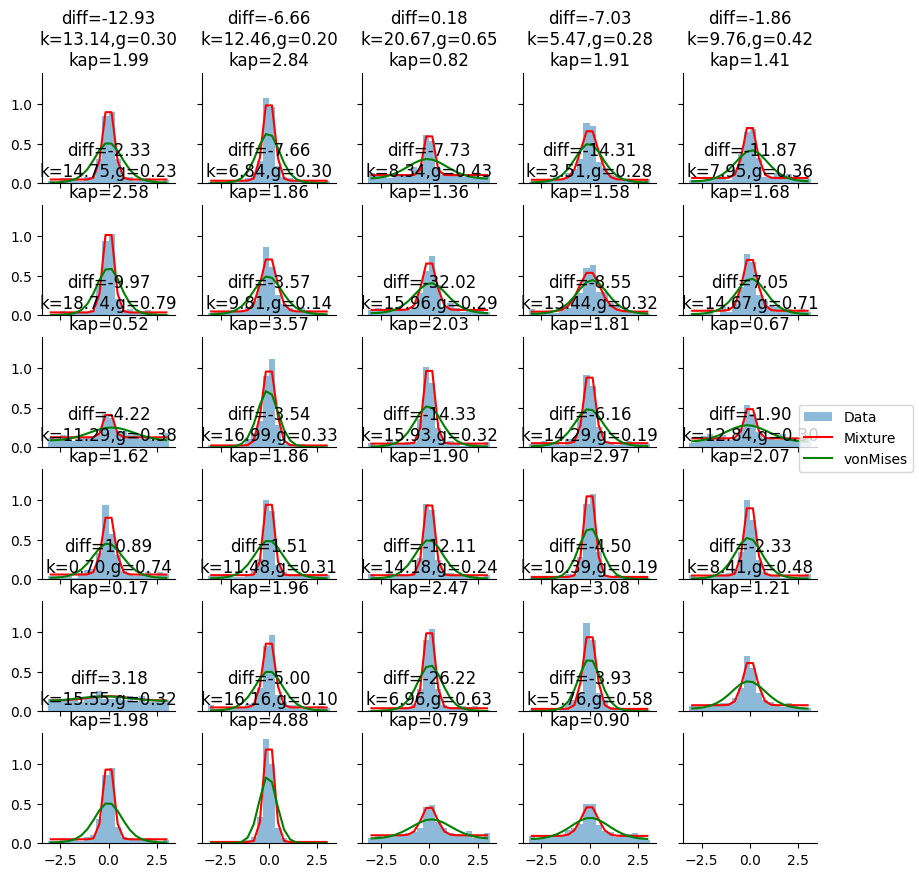

In [4]:
import matplotlib.pyplot as plt
import seaborn
from scipy.stats import vonmises

fig,ax = plt.subplots(6,5,figsize=(10,10),sharex=True,sharey=True)
participantIndex = 0

for participant in participantList:
    participantData = testData[testData['Subject']==participant]

    guessRateFit = jlib.compression.preprocessing.fitGuessingOnCircle(participantData['Response error']*numpy.pi/180,
                                                                      initParams=[1,0.5],
                                                                      paramBounds=[(0.01,50),(0,1)])
    kappa,guessing = guessRateFit.x

    vonmisesFit = vonmises.fit(participantData['Response error']*numpy.pi/180,scale=1)

    hist,binEdges = numpy.histogram(participantData['Response error']*numpy.pi/180,
                                    bins=20,range=(-numpy.pi, numpy.pi),density=True)
    binCenters = (binEdges[:-1]+binEdges[1:])/2

    axX = participantIndex%5
    axY = numpy.int64(numpy.floor(participantIndex/5))

    labels = ["","",""]
    if (participantIndex==0):
        labels = ["Data","Mixture","vonMises"]
    ax[axY,axX].hist(participantData['Response error']*numpy.pi/180,bins=20,range=(-numpy.pi, numpy.pi),
                     density=True,alpha=0.5,label=labels[0])
    ax[axY,axX].plot(binCenters,
                     jlib.compression.preprocessing._guessingOnCircleModel(binCenters,kappa,guessing),
                     'r-',label=labels[1])
    ax[axY,axX].plot(binCenters,
                     vonmises.pdf(binCenters,vonmisesFit[0],loc=vonmisesFit[1]),
                     'g-',label=labels[2])

    participantIndex += 1

    medianData = participantData.loc[:,['Trial type','Response error (absolute)']].groupby(['Trial type']).median().reset_index()
    patternedData = medianData[medianData['Trial type']=='Chunkable']['Response error (absolute)'].to_numpy()
    randomData = medianData[medianData['Trial type']=='Non-chunkable']['Response error (absolute)'].to_numpy()
        
    ax[axY,axX].title.set_text(f'diff={(patternedData-randomData)[0]:.2f}\nk={kappa:.2f},g={guessing:.2f}\nkap={vonmisesFit[0]:.2f}')

seaborn.despine()
fig.legend(loc="center right")

In [5]:
print(allParticipantData_long.shape)
test = allParticipantData_long[~allParticipantData_long['Subject'].isin(participantsToExclude)].copy()
print(test.shape)

allParticipantData_long = test

(14949, 16)
(12423, 16)


## <span style='color:Red'>Preprocess questionnaire data</span>

In [6]:
questionnaireFilePath = '../../experiment4_EEG/data/pilot/post/'

questionnaireFieldsToRename = {'Participant':'Subject'}

postData = pandas.read_excel(questionnaireFilePath + 'Exp4_Questionnaire.xlsx')
postData.rename(columns=questionnaireFieldsToRename,inplace=True)

filteredData = postData[postData['Subject'].isin(numpy.unique(allParticipantData_long['Subject']))]
counterF = filteredData[filteredData['Sex']=='F'].shape[0]

mapValueHandler.setKeyValue("participantCountF",f'{counterF:.0f}')
mapValueHandler.setKeyValue("participantCountM",f'{filteredData.shape[0]-counterF:.0f}')
mapValueHandler.setKeyValue("participantAgeMean",f'{numpy.nanmean(filteredData["AgeYears"].to_numpy()):.2f}')
mapValueHandler.setKeyValue("participantAgeSTD",f'{numpy.nanstd(filteredData["AgeYears"].to_numpy()):.2f}')
mapValueHandler.setKeyValue("participantsNoAge",f'{filteredData["AgeYears"].isna().sum():.0f}')

## <span style='color:Red'>Save all data</span>

In [7]:
allParticipantData_long.to_csv(exportsPath+'participantData_long.csv',index=False)
# allParticipantData_wide.to_csv(exportsPath+'participantData_wide.csv',index=False)
mapValueHandler.saveData()

All data saved correctly to exports/exp4Values.csv
